<a href="https://colab.research.google.com/github/Gcarmnonapy7/FIAP-Aurora-Siger/blob/main/Aurora_siger.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

# Entregáveis do Projeto Aurora SIGER

Roteiro de desenvolvimento do trabalho em grupo. Cada seção abaixo corresponde a um entregável da atividade.

## 1.1 Organização e descrição da telemetria

Interpretar dados referentes a:
- Temperatura interna e externa
- Integridade estrutural (0/1)
- Níveis de energia (%)
- Pressão dos tanques
- Status dos módulos críticos

## 1.2 Algoritmo de verificação

Construir um algoritmo (fluxograma/pseudocódigo) capaz de decidir:
- **"PRONTO PARA DECOLAR"** ou **"DECOLAGEM ABORTADA"**

Com base em faixas seguras predefinidas para cada variável de telemetria.

## 1.3 Script em Python

Implementar a lógica do algoritmo em Python, simulando:
- Leitura dos dados de telemetria
- Execução das verificações contra faixas seguras
- Resultado final impresso: **"PRONTO PARA DECOLAR"** ou **"DECOLAGEM ABORTADA"**

## 1.4 Análise energética

Calcular autonomia inicial considerando:
- Capacidade total (kWh)
- Carga atual (%)
- Consumo estimado na decolagem
- Perdas energéticas

## 1.5 Análise assistida por IA

Solicitar à IA:
- Classificação dos dados de telemetria
- Identificação de possíveis anomalias
- Sugestões de risco

## 1.6 Reflexão crítica

Texto sobre:
- Ética e responsabilidade no uso de IA e automação em sistemas críticos
- Impacto social da exploração espacial
- Sustentabilidade tecnológica

### Pipeline de Machine Learning

```
DATA LOADING & CLEANING → EDA → FEATURE ENGINEERING → DATA SPLITTING → TRAINING → VALIDATION ⇄ HYPERPARAMETER TUNING → SAVE ARTEFACT
```

> **Nota:** Validação e Hyperparameter Tuning formam um ciclo iterativo — ajusta-se, valida-se, repete-se até encontrar a melhor configuração.

| Etapa | O que faz |
|-------|-----------|
| **Data Loading & Cleaning** | Carregar os dados brutos e tratar valores ausentes, duplicados ou inconsistentes |
| **EDA** (Exploratory Data Analysis) | Visualizar distribuições, correlações e padrões para entender os dados antes de modelar |
| **Feature Engineering** | Criar, transformar ou selecionar variáveis que melhorem a capacidade preditiva do modelo |
| **Data Splitting** | Dividir em treino, validação e teste para avaliar o modelo em dados que ele nunca viu |
| **Training** | Ajustar os parâmetros do modelo aos dados de treino |
| **Validation** | Medir o desempenho em dados de validação para detectar overfitting ou underfitting |
| **Hyperparameter Tuning** | Otimizar configurações externas ao modelo (ex: número de árvores, kernel) que não são aprendidas no treino |
| **Save Artefact** | Serializar o modelo treinado (ex: `joblib`, `pickle`) para uso em produção |

In [17]:
# === import libraries ===

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from collections import Counter

In [18]:
np.random.seed(42)
n_samples = 100_000
anomalies_ratio = 0.03
n_anomalies = int(n_samples * anomalies_ratio)

In [19]:
tank_pressure_data = np.random.normal(loc=305, scale=15, size=n_samples - n_anomalies)

failure_prob = 1 / (1 + np.exp(-(tank_pressure_data - 340) / 5))
failure_prob = np.clip(failure_prob, 0, 1)

df_non_anomaly = pd.DataFrame({
    'internal_temp': np.random.normal(loc=22, scale=1.5, size=n_samples - n_anomalies),
    'external_temp': np.random.normal(loc=10, scale=8, size=n_samples - n_anomalies),
    'structural_integrity': np.random.binomial(1, 1 - failure_prob),
    'energy': np.clip(np.random.normal(loc=98, scale=2, size=n_samples - n_anomalies), 0, 100),
    'vibration': np.random.normal(loc=0.3, scale=0.1, size=n_samples - n_anomalies),
    'tank_pressure': tank_pressure_data,
    'critical_modules': np.random.binomial(1, 1 - failure_prob, size=n_samples - n_anomalies)
})

In [20]:
# --- ANOMALY PRESSURE (shift distribution) ---
tank_pressure_anomaly = np.random.normal(loc=360, scale=25, size=n_anomalies)

# Higher failure probability (more aggressive sigmoid)
failure_prob_anomaly = 1 / (1 + np.exp(-(tank_pressure_anomaly - 300) / 5))
failure_prob_anomaly = np.clip(failure_prob_anomaly, 0, 1)

internal_temp =  np.concatenate(
       [np.random.normal(35,3,size=n_anomalies//2),
        np.random.normal(5,2,size=n_anomalies//2)]
        # need to divide it for the right number
    ) # internal temp (extreme)

np.random.shuffle(internal_temp)

structural_integrity = np.clip(np.random.binomial(
    1,
    0.3 + 0.4*(1 - failure_prob_anomaly)
),0,1)

df_anomaly = pd.DataFrame({
    'internal_temp': internal_temp,
    'external_temp': np.random.normal(loc=60, scale=20, size=n_anomalies),
    'structural_integrity': np.random.binomial(1, 1 - failure_prob_anomaly),
    'energy': np.clip(np.random.normal(loc=40, scale=15, size=n_anomalies), 0, 100),
    'vibration': np.random.normal(loc=1.2, scale=0.4, size=n_anomalies),
    'tank_pressure' : tank_pressure_anomaly,
    'critical_modules': np.random.binomial(1,failure_prob_anomaly, size=n_anomalies)})


# === anomaly columns ===

df_non_anomaly['anomaly'] = 0
df_anomaly['anomaly'] = 1

init_dataframe = pd.concat([df_non_anomaly,df_anomaly]).reset_index(drop=True)

In [21]:
print(f'Dataframe shape: {init_dataframe.shape}')

Dataframe shape: (100000, 8)


In [22]:
init_dataframe.head(5)

,internal_temp,external_temp,structural_integrity,energy,vibration,tank_pressure,critical_modules,anomaly
0,24.613473,8.821301,1,97.030465,0.252697,312.450712,1,0
1,21.841330,3.264808,1,94.998383,0.358674,302.926035,1,0
2,21.895316,18.606012,1,99.018895,0.368379,314.715328,1,0
3,21.713747,26.772365,1,97.684462,0.200000,327.845448,1,0
4,22.831218,11.177638,1,97.510682,0.358084,301.487699,1,0


In [23]:
init_dataframe.describe()

,internal_temp,external_temp,structural_integrity,energy,vibration,tank_pressure,critical_modules,anomaly
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,21.938870,11.483076,0.947960,96.086805,0.326619,306.667210,0.977270,0.030000
std,3.030864,12.109886,0.222109,10.385281,0.195698,18.042894,0.149042,0.170588
min,-1.344384,-25.311088,0.000000,0.000000,-0.204319,238.015942,0.000000,0.000000
25%,20.953659,4.759043,1.000000,96.485988,0.234321,295.242851,1.000000,0.000000
50%,21.999259,10.287221,1.000000,97.913460,0.303386,305.593588,1.000000,0.000000
75%,23.045546,15.970377,1.000000,99.298147,0.374750,316.250486,1.000000,0.000000
max,45.327927,134.972857,1.000000,100.000000,2.716765,449.045786,1.000000,1.000000


## EDA (Exploratory data analysis)

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# === Plot configurations ===
sns.set_style("dark", {
    "axes.facecolor": "black",
    "figure.facecolor": "black",
    "grid.color": "#222222", # Very faint grid
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white"
})
sns.set_context('talk') # bold text for readable
sns.despine() # remove the top and right spines

def heatmap_plot(data:pd.DataFrame) -> None:
    plt.figure(figsize=(7.5,6))
    plt.title('Heatmap of the correlation between variables')
    corr = data.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool)) # upper triangular (down visualization) for easier visualization
    sns.heatmap(corr,mask=mask,annot=True,fmt=".2f")
    plt.show()

def distribution_plot(data: pd.DataFrame) -> None:

    n_vars = len(data.columns)
    n_cols = 2
    n_rows = (n_vars + n_cols - 1) // n_cols

    plt.figure(figsize=(16, 4*n_rows))

    for idx, col in enumerate(data.columns, start=1):

        plt.subplot(n_rows, n_cols, idx)

        sns.histplot(
            data[col],
            kde=True,
            bins=25,
            color="#4C72B0",
            edgecolor="black"
        )

        plt.title(f"Distribution of {col}", fontsize=12, fontweight="bold")
        plt.xlabel(col)
        plt.ylabel("Frequency")

    plt.suptitle("Feature Distributions", fontsize=18, fontweight="bold")

    plt.tight_layout(rect=[0,0,1,0.96])
    plt.show()

def boxplot_(data:pd.DataFrame):

  n_vars = len(data.columns)
  n_cols = 3
  n_rows = (n_vars + n_cols -1) // n_cols

  plt.figure(figsize=(16,4*n_rows))
  for idx, col in enumerate(data.columns):

        plt.subplot(n_rows, n_cols, idx + 1)

        sns.boxenplot(
            x=data[col],
            color="#4C72B0"
        )

        plt.title(f"{col}", fontsize=12, fontweight="bold")

  plt.suptitle("Feature Distribution Overview", fontsize=18, fontweight="bold")

  plt.tight_layout()
  plt.show()

<Figure size 640x480 with 0 Axes>

In [25]:
def pairplot_data(data: pd.DataFrame):
    if data is None or data.empty:
        print("Dataframe is empty")
        return

    # No loop, no manual subplots needed
    # corner=True removes the mirrored top-half for better readability
    sns.pairplot(data, hue='anomaly', corner=True, palette='coolwarm')
    plt.suptitle("Feature Inter-correlations by Anomaly", y=1.02, fontsize=16)
    plt.show()

<Figure size 500x500 with 0 Axes>

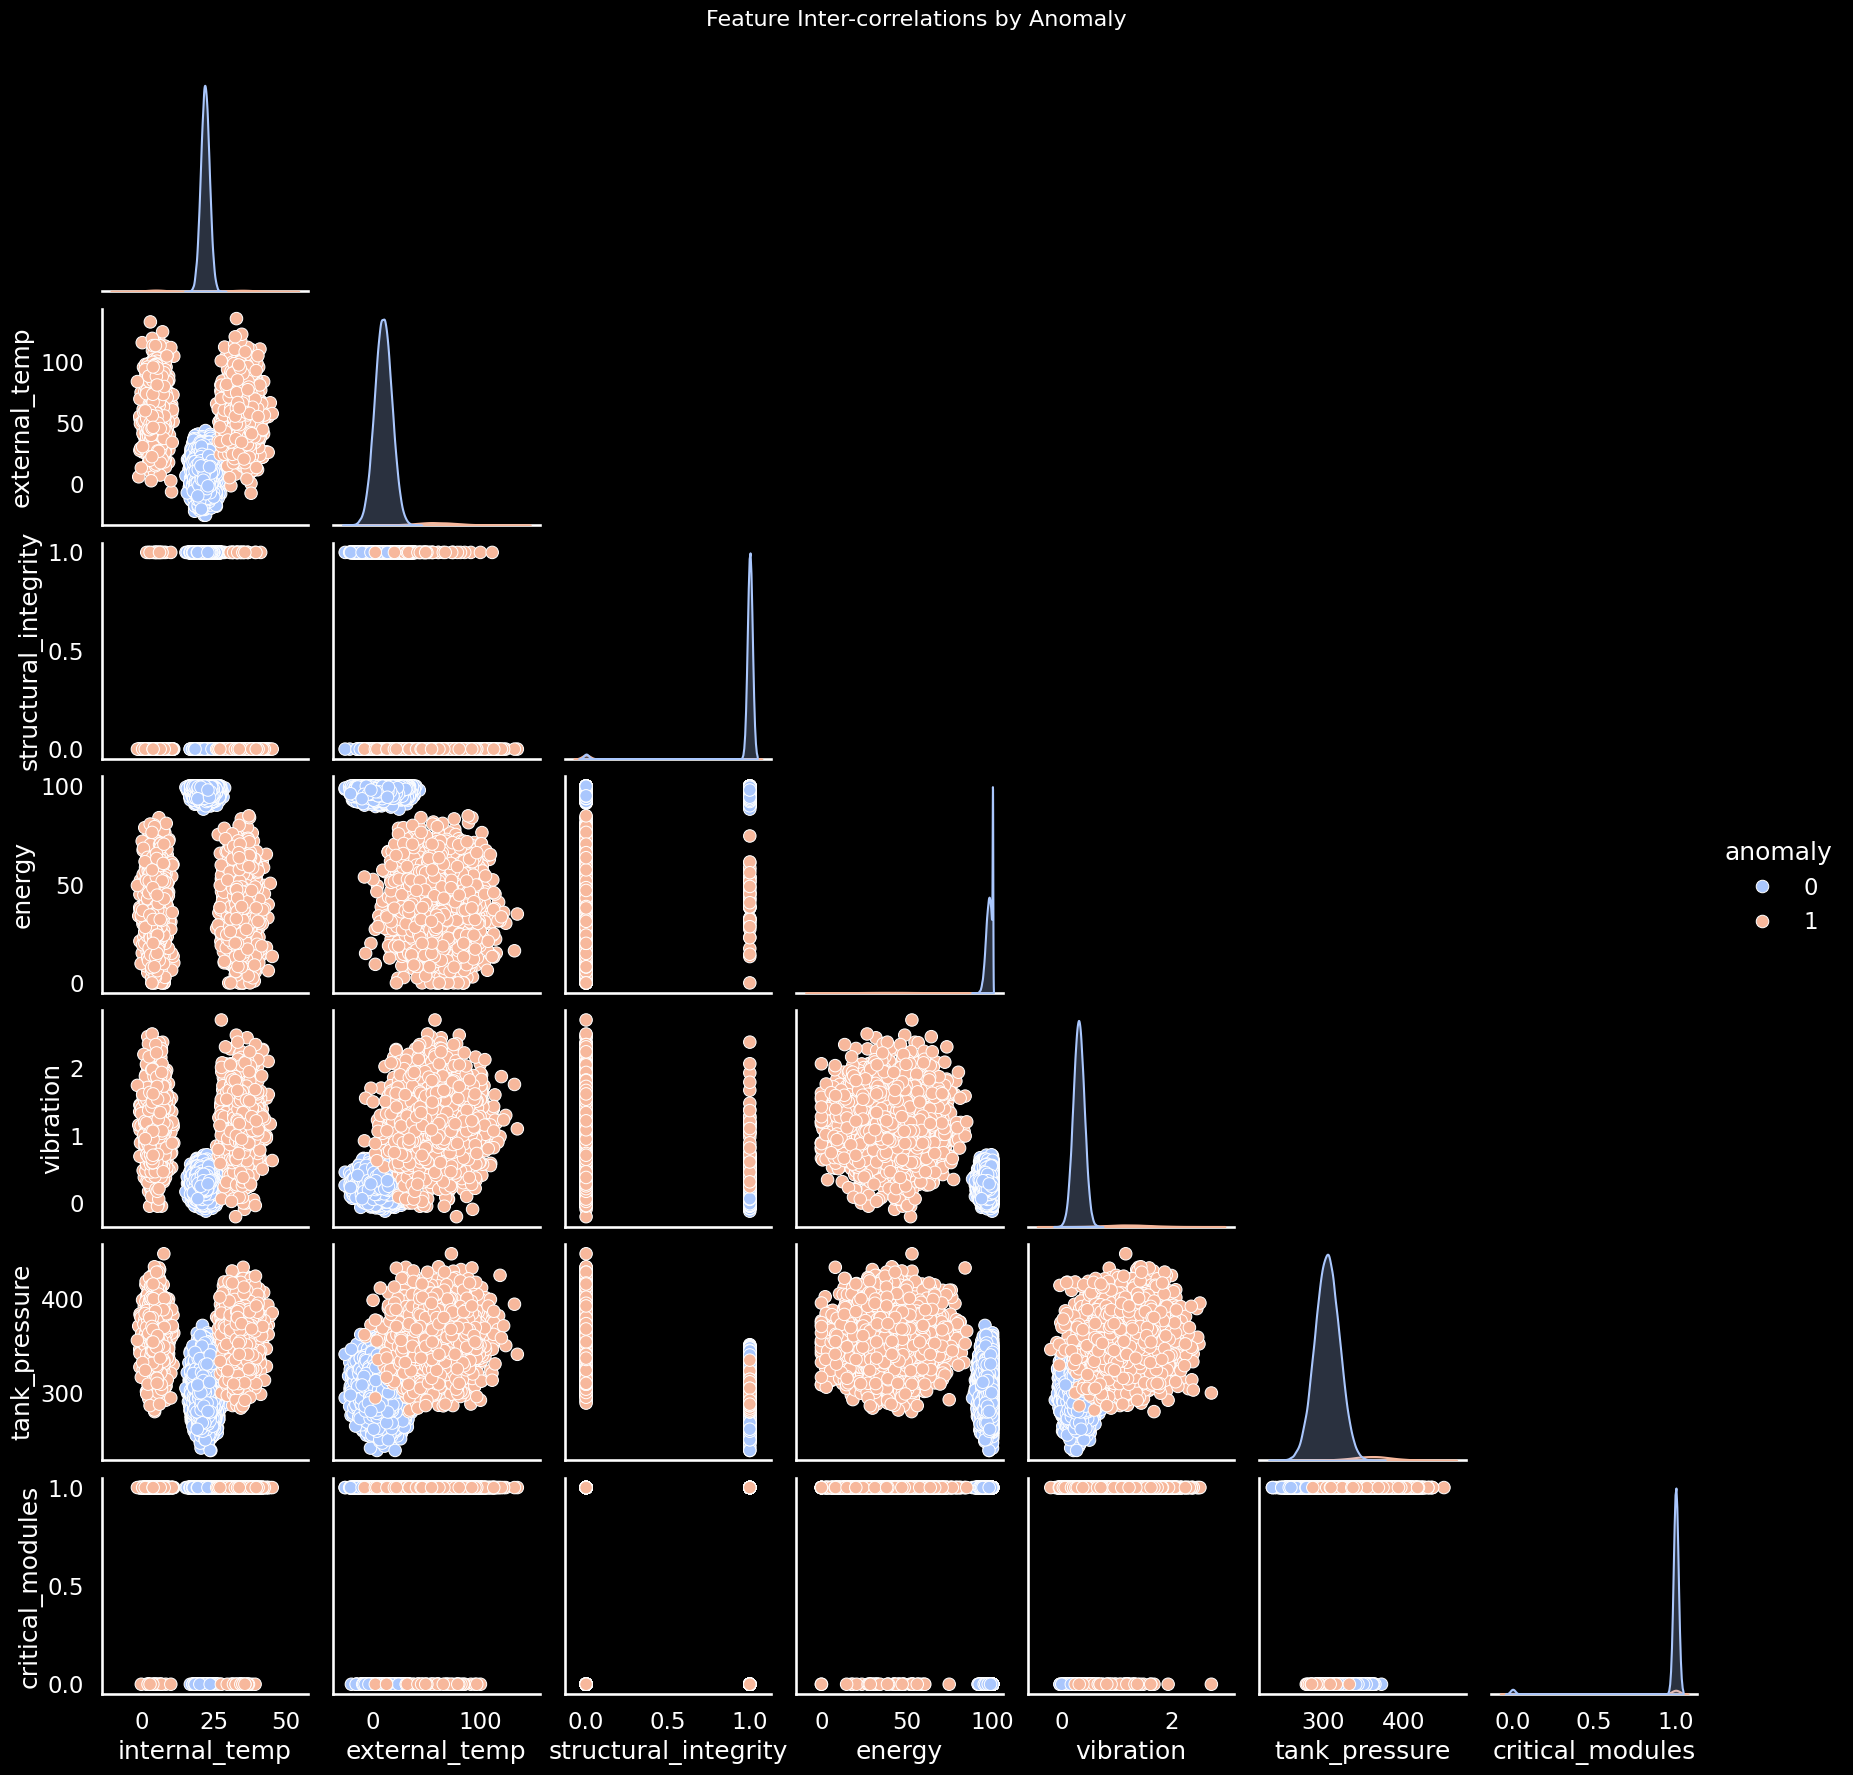

In [26]:
pairplot_data(init_dataframe)

In [27]:
import plotly.io as pio
pio.renderers.default = "colab"

def visualization_3D_anomaly(data: pd.DataFrame, x_axis: str, y_axis: str, z_axis: str):

    if data is None or data.empty:
        print("Dataframe is empty.")
        return

    required_cols = [x_axis, y_axis, z_axis, "anomaly"]

    for col in required_cols:
        if col not in data.columns:
            print(f"Column '{col}' not found in dataframe.")
            return

    fig = px.scatter_3d(
        data,
        x=x_axis,
        y=y_axis,
        z=z_axis,
        color="anomaly",
        opacity=0.5,
        title=f"3D Anomaly Visualization: {x_axis} vs {y_axis} vs {z_axis} (Partialy...)"
    )

    fig.update_layout(
        scene=dict(
            xaxis_title=x_axis,
            yaxis_title=y_axis,
            zaxis_title=z_axis
        ),
        width=900,
        height=700,
        legend_title="Anomaly"
    )

    fig.show()


normal = init_dataframe.sample(12000) # 12000 samples for plotting

visualization_3D_anomaly(
    normal,
    "tank_pressure",
    "internal_temp",
    "vibration"
)

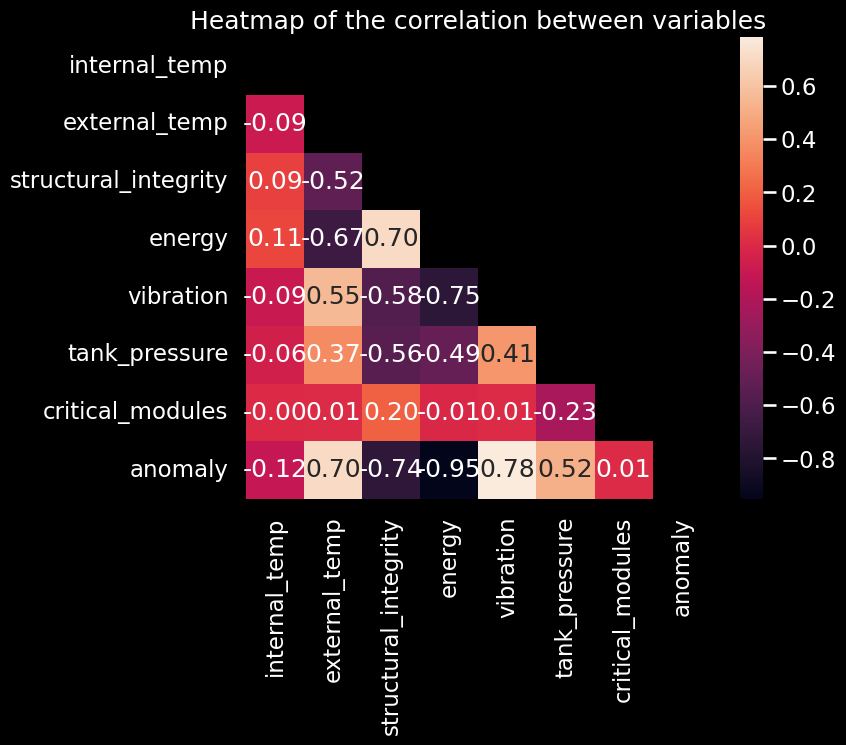

In [28]:
heatmap_plot(init_dataframe)

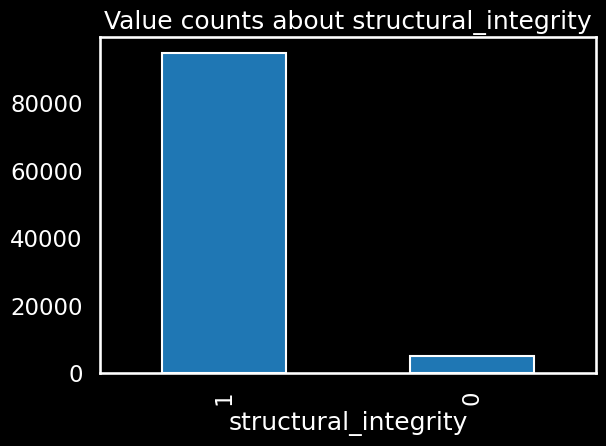

In [29]:
## exploring the data
plt.title("Value counts about structural_integrity")
init_dataframe['structural_integrity'].value_counts().plot(kind="bar")
plt.tight_layout()
plt.show()

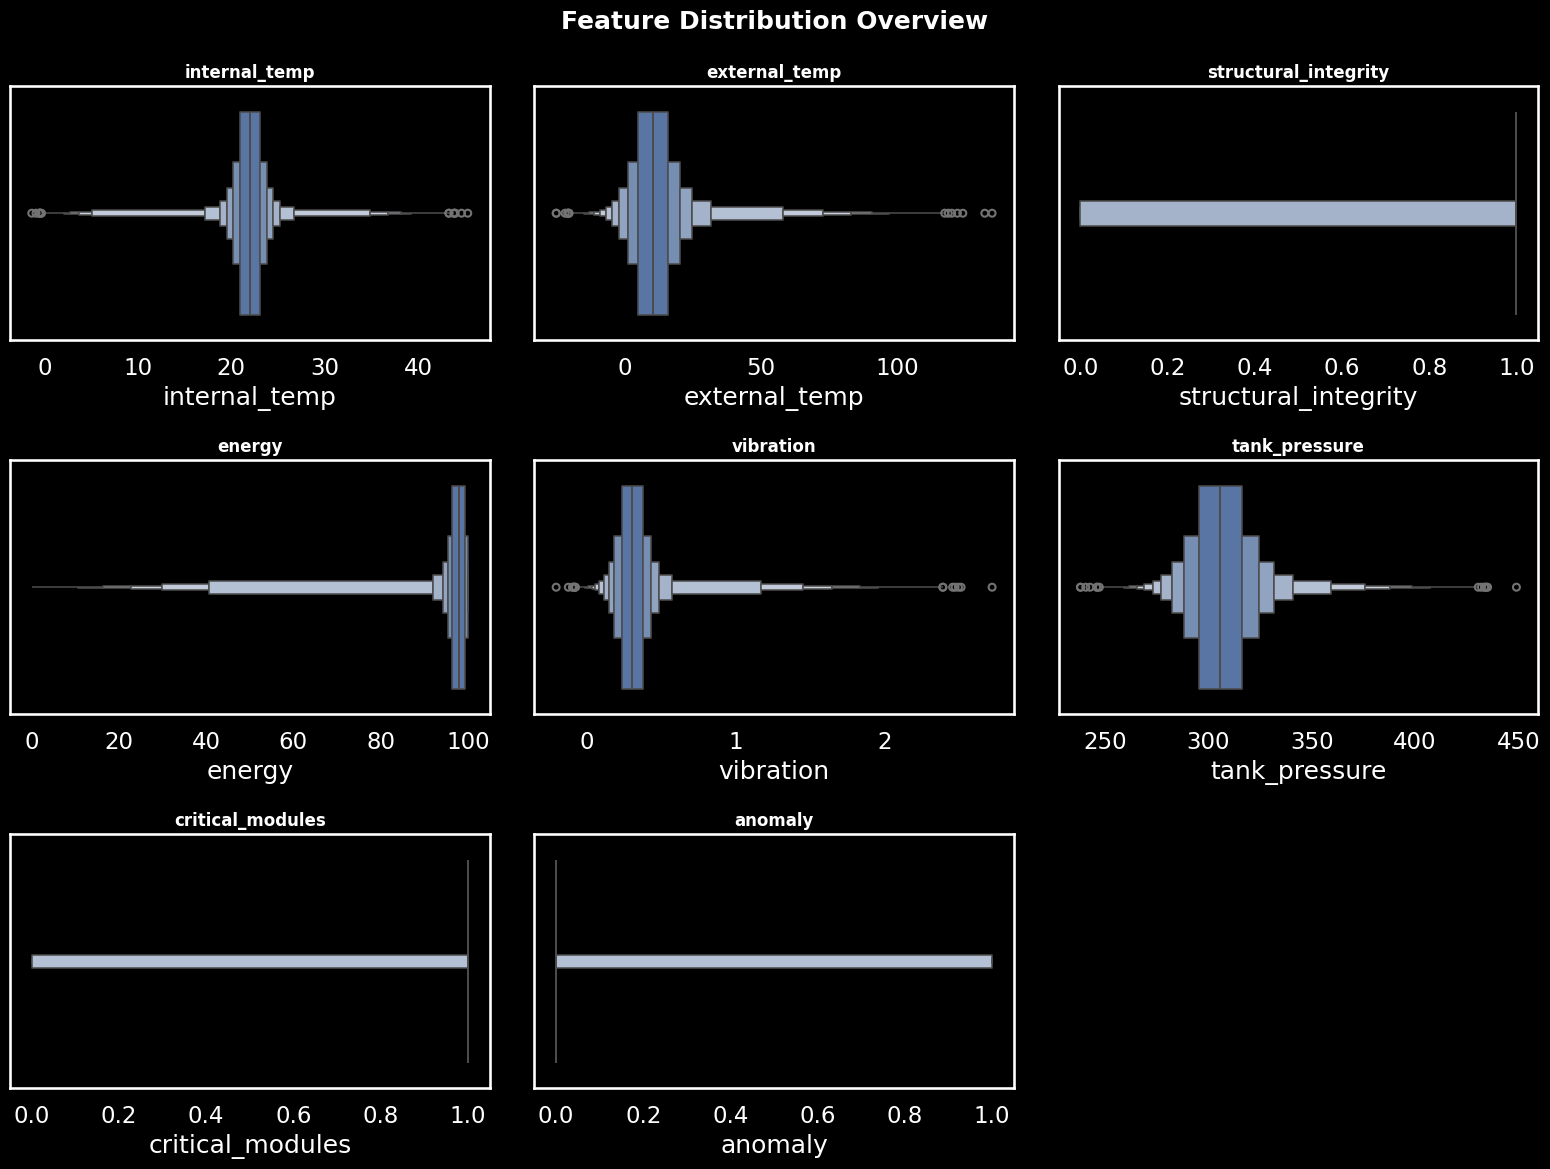

In [30]:
boxplot_(data=init_dataframe)

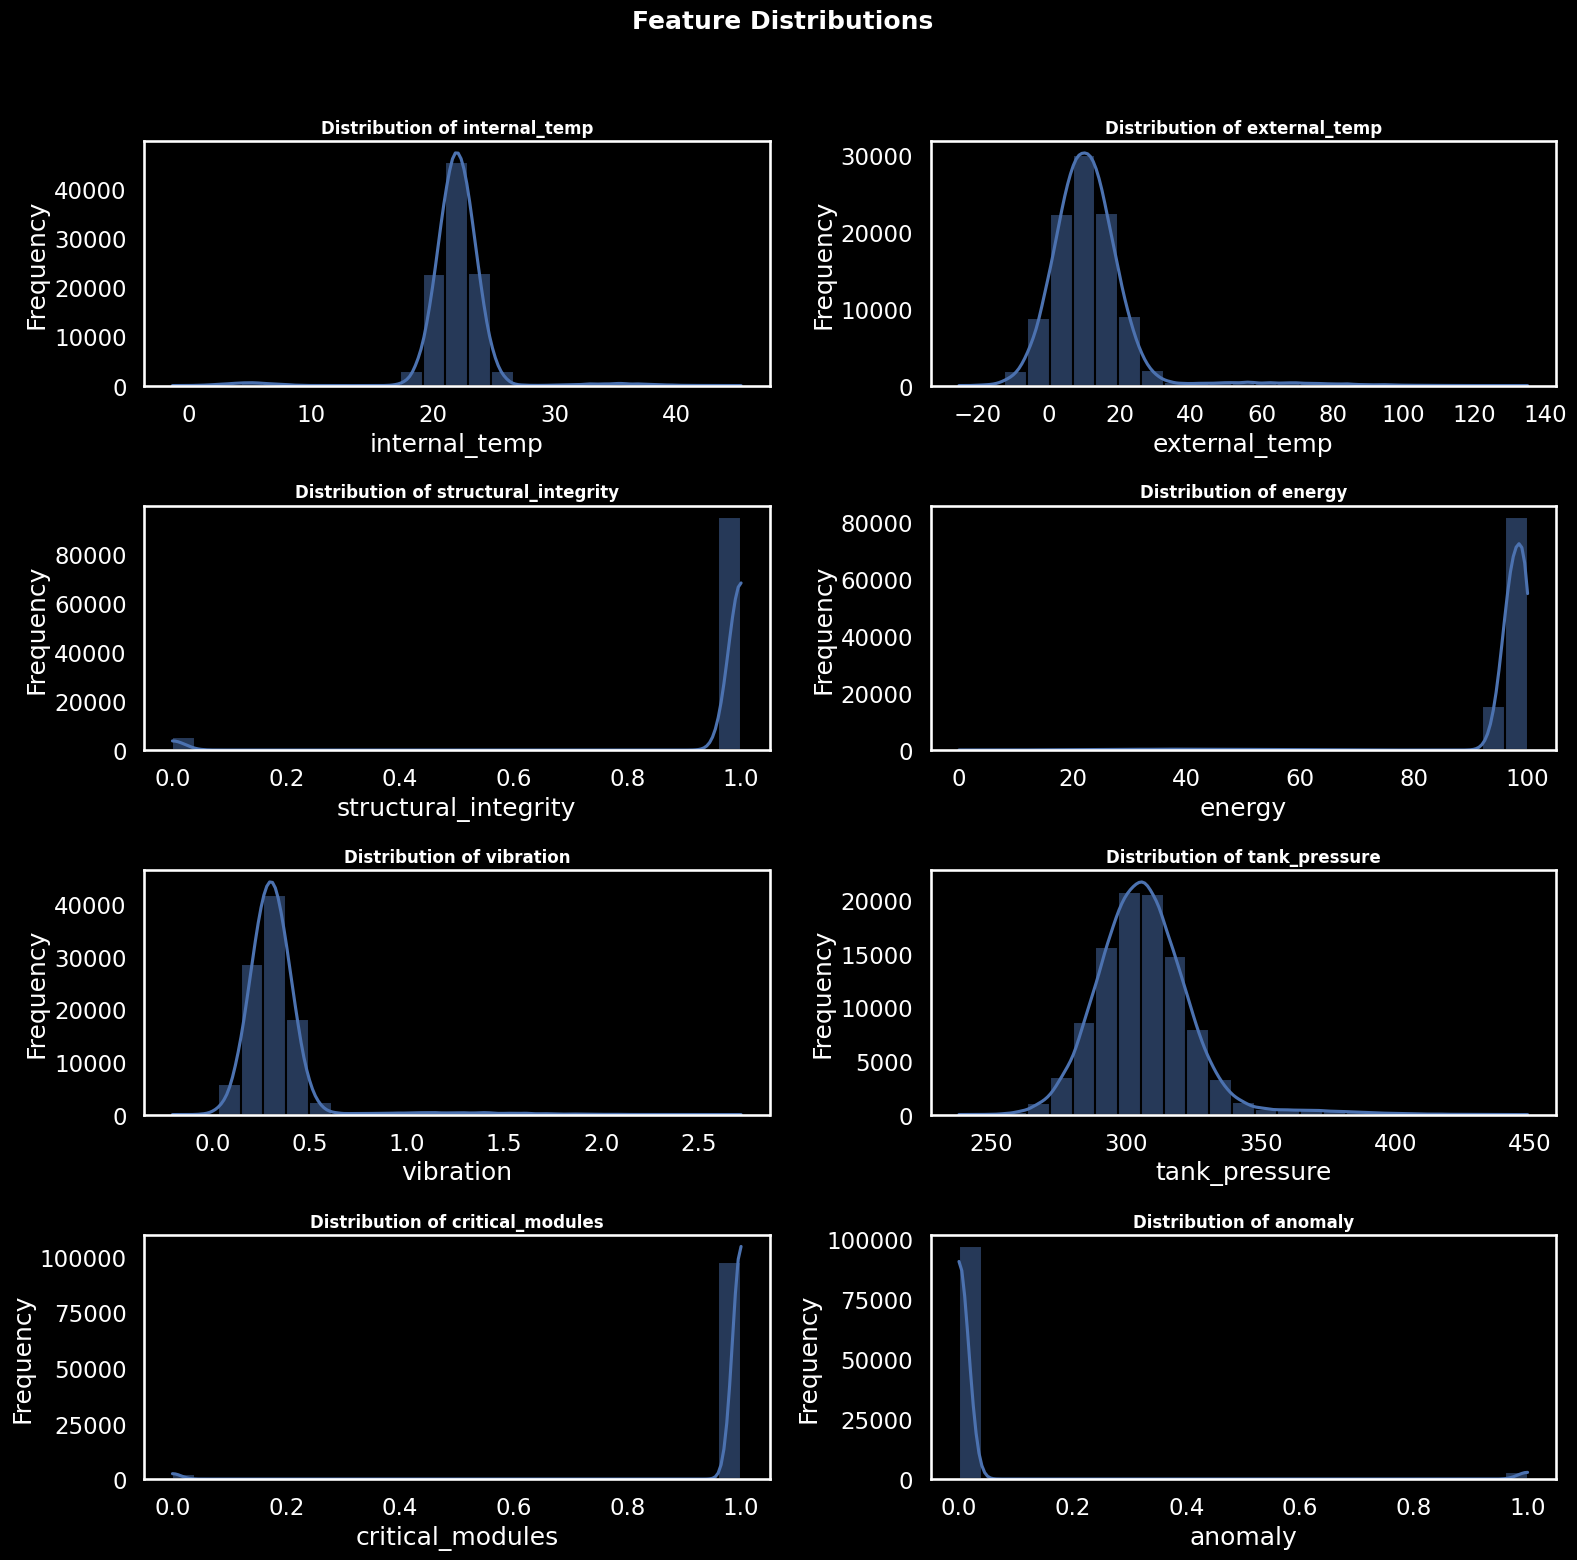

In [31]:
distribution_plot(data=init_dataframe)

##Creating the models from scratch

In [32]:
class IsolationTreeNode:
  def __init__(self,feature=None,threshold=None,left=None,right=None,size=None):
    self.feature = feature
    self.threshold = threshold
    self.left = left
    self.right = right
    self.size = size

In [33]:
class  IsolationTree:

  def __init__(self,max_depth):

    self.max_depth = max_depth
    self.root = None

  def fit(self,X):

    self.root = self._grow_tree(X,depth=0)

  def _grow_tree(self, X, depth):

    n_samples, n_features = X.shape

    if depth >= self.max_depth or n_samples <= 1:
        return IsolationTreeNode(size=n_samples)

    feature = np.random.randint(0, n_features)

    min_val = X[:, feature].min()
    max_val = X[:, feature].max()

    if min_val == max_val:
        return IsolationTreeNode(size=n_samples)

    threshold = np.random.uniform(min_val, max_val)

    left_mask = X[:, feature] < threshold
    right_mask = X[:, feature] >= threshold

    # Prevent empty branches
    if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
        return IsolationTreeNode(size=n_samples)

    left = self._grow_tree(X[left_mask], depth + 1)
    right = self._grow_tree(X[right_mask], depth + 1)

    return IsolationTreeNode(feature, threshold, left, right)

  def path_length(self,x):
    return self._path_length(x,self.root,0)

  def _path_length(self,x,node,depth):

    if node.size is not None:
      return depth + self._c(node.size)

    if x[node.feature] < node.threshold:
      return self._path_length(x,node.left, depth + 1 )
    else :
      return self._path_length(x,node.right,depth + 1)

  def _c(self,n):
    """
    Computes the average path length of an unsuccessful search in a BST.

    In the context of Isolation Forests, this value serves as a normalization
    factor. It represents the 'expected' depth for a node in a tree built
    from 'n' data points.

    If an actual data point has a path length significantly shorter than this
    theoretical average, it is considered more "isolated" and thus an anomaly.

    Args:
        n (int): Number of nodes/samples in the tree.

    Returns:
        float: The harmonic-based average path length.
    """

    if n <= 1:
      return 0

    # 0.5772156649 is the Euler-Mascheroni constant (gamma).
    # We use (log(n-1) + gamma) to efficiently approximate the
    # n-th Harmonic number, H(i).

    return 2 * (np.log(n - 1) + 0.5772156649) - (2 * (n - 1) / n)


In [34]:
class MyIsolationForest:

  def __init__(self,n_trees,sample_size):
    self.n_trees = n_trees
    self.sample_size = sample_size
    self.trees = []

  def fit(self,X):

    self.trees = []
    n_samples = X.shape[0]

    max_depth = int(np.ceil(np.log2(self.sample_size)))

    for _ in range(self.n_trees):

      idxs = np.random.choice(n_samples,self.sample_size,replace=False)
      sample = X[idxs]

      tree = IsolationTree(max_depth)
      tree.fit(sample)

      self.trees.append(tree)

  def anomaly_score(self,X):

    scores = []

    for x in X:

      path_lengths = [tree.path_length(x) for tree in self.trees]

      avg_path = np.mean(path_lengths)

      c = self._c(self.sample_size)

      score = 2 ** (-avg_path / c)

      scores.append(score)

    return np.array(scores) # Changed from np.array(score)

  def _c(self,n):
    """
    Computes the average path length of an unsuccessful search in a BST.

    In the context of Isolation Forests, this value serves as a normalization
    factor. It represents the 'expected' depth for a node in a tree built
    from 'n' data points.

    If an actual data point has a path length significantly shorter than this
    theoretical average, it is considered more "isolated" and thus an anomaly.

    Args:
        n (int): Number of nodes/samples in the tree.

    Returns:
        float: The harmonic-based average path length.
    """

    if n <= 1:
      return 0

    # 0.5772156649 is the Euler-Mascheroni constant (gamma).
    # We use (log(n-1) + gamma) to efficiently approximate the
    # n-th Harmonic number, H(i).

    return 2 * (np.log(n - 1) + 0.5772156649) - (2 * (n - 1) / n)


  def predict(self,X,contamination=0.03):

    scores = self.anomaly_score(X)

    threshold = np.percentile(scores,100 *  (1 - contamination))
    return np.where(scores >= threshold,-1,1) # -1 anomaly , 1 normal

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


X = init_dataframe.drop(columns=["anomaly"]).values
y = init_dataframe["anomaly"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    stratify=y,
    test_size=0.2,
    random_state=42
)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

my_model = MyIsolationForest(
    n_trees=100, # Changed from n_trees
    sample_size=256   # Changed from sample_size
)


In [36]:
# ===== SCRATCH MODEL =====

my_model.fit(X_train) # Added: Fit the custom Isolation Forest model

train_scores = my_model.anomaly_score(X_train)

threshold = np.percentile(train_scores, 97)

test_scores = my_model.anomaly_score(X_test)

preds = np.where(test_scores >= threshold, 1, 0)

print("Scratch Model")
print(classification_report(y_test, preds))

scratch_auc = roc_auc_score(y_test, test_scores)
print("Scratch ROC AUC:", scratch_auc)


# ===== SKLEARN MODEL =====

sk_model = IsolationForest(
    n_estimators=100,
    max_samples=256,
    contamination=0.03,
    random_state=42
)

sk_model.fit(X_train)

sk_preds = sk_model.predict(X_test)
sk_preds = np.where(sk_preds == -1, 1, 0)

print("Sklearn Model")
print(classification_report(y_test, sk_preds))

sk_scores = -sk_model.decision_function(X_test)

sk_auc = roc_auc_score(y_test, sk_scores)

print("Sklearn ROC AUC:", sk_auc)

Scratch Model
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19400
           1       0.85      0.85      0.85       600

    accuracy                           0.99     20000
   macro avg       0.92      0.92      0.92     20000
weighted avg       0.99      0.99      0.99     20000

Scratch ROC AUC: 0.9983487972508591
Sklearn Model
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19400
           1       0.99      0.99      0.99       600

    accuracy                           1.00     20000
   macro avg       0.99      0.99      0.99     20000
weighted avg       1.00      1.00      1.00     20000

Sklearn ROC AUC: 0.9999534364261169


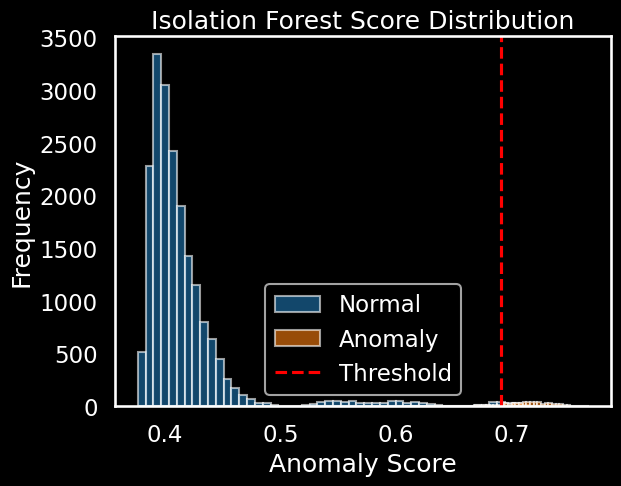

In [37]:
plt.hist(test_scores[y_test == 0], bins=50, alpha=0.6, label="Normal")
plt.hist(test_scores[y_test == 1], bins=50, alpha=0.6, label="Anomaly")

plt.axvline(threshold, color='red', linestyle='--', label='Threshold')

plt.title("Isolation Forest Score Distribution")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.legend()

plt.show()

In [38]:
# === Comparing model metrics ===

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC AUC"]

# Scratch metrics
scratch_accuracy = accuracy_score(y_test, preds)
scratch_precision = precision_score(y_test, preds)
scratch_recall = recall_score(y_test, preds)
scratch_f1 = f1_score(y_test, preds)

# Sklearn metrics
sk_accuracy = accuracy_score(y_test, sk_preds)
sk_precision = precision_score(y_test, sk_preds)
sk_recall = recall_score(y_test, sk_preds)
sk_f1 = f1_score(y_test, sk_preds)

sklearn_scores = [
    sk_accuracy,
    sk_precision,
    sk_recall,
    sk_f1,
    sk_auc
]

scratch_scores = [
    scratch_accuracy,
    scratch_precision,
    scratch_recall,
    scratch_f1,
    scratch_auc
]

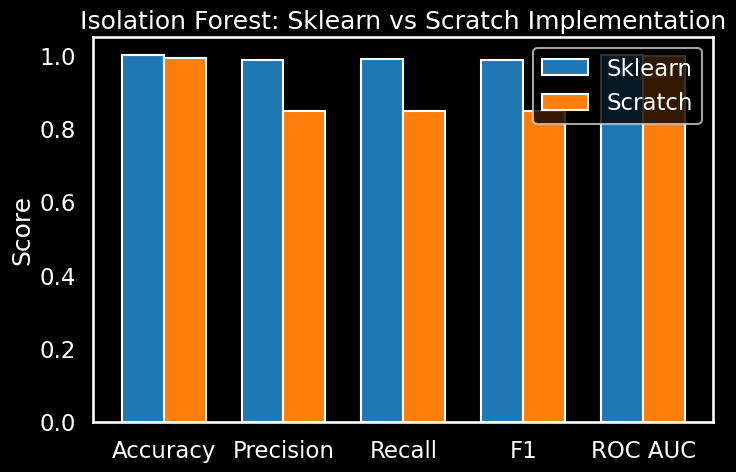

In [39]:
x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, sklearn_scores, width, label="Sklearn")
plt.bar(x + width/2, scratch_scores, width, label="Scratch")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Isolation Forest: Sklearn vs Scratch Implementation")
plt.legend()

plt.show()

In [40]:
# ============================================================
# 1 — VALIDADOR DE TELEMETRIA
# ============================================================

class Validator:

    RULES = {
        'internal_temp':        {'type': 'range',  'min': 18,   'max': 26},
        'external_temp':        {'type': 'range',  'min': -65,  'max': 125},
        'structural_integrity': {'type': 'binary', 'expected': 1},
        'energy':               {'type': 'range',  'min': 60,   'max': None},
        'vibration':            {'type': 'range',  'min': 0.1,  'max': 0.5},
        'tank_pressure':        {'type': 'range',  'min': 270,  'max': 340},
        'critical_modules':     {'type': 'binary', 'expected': 1},
    }

    def __init__(self, df: pd.DataFrame):
        self.df = df

    def validate_item(self, item) -> bool:

        for col, rule in self.RULES.items():

            value = item[col]

            if rule['type'] == 'binary':
                if value != rule['expected']:
                    return False

            else:
                mn, mx = rule.get('min'), rule.get('max')

                if mn is not None and value < mn:
                    return False

                if mx is not None and value > mx:
                    return False

        return True

    def validate_item_detail(self, item):

        result = {}

        for col, rule in self.RULES.items():

            value = item[col]

            if rule['type'] == 'binary':

                result[col] = "OK" if value == rule['expected'] else "FAILED"

            else:

                mn, mx = rule.get('min'), rule.get('max')

                if mn is not None and value < mn:
                    result[col] = f"FAILED ({value} < {mn})"

                elif mx is not None and value > mx:
                    result[col] = f"FAILED ({value} > {mx})"

                else:
                    result[col] = "OK"

        return result


# ============================================================
# 2 — VERIFICAÇÃO DE IA
# ============================================================

def ai_anomaly_check(reading, model, scaler, threshold):

    print("\n=== IA ANOMALY CHECK ===")

    features = np.array([[
        reading["internal_temp"],
        reading["external_temp"],
        reading["structural_integrity"],
        reading["energy"],
        reading["vibration"],
        reading["tank_pressure"],
        reading["critical_modules"]
    ]])

    X_scaled = scaler.transform(features)

    score = model.anomaly_score(X_scaled)[0]

    print(f"Anomaly Score: {score:.4f}")

    if score >= threshold:
        print("⚠ IA detectou anomalia")
        return False

    print("IA não detectou anomalias")

    return True


# ============================================================
# 3 — ANÁLISE ENERGÉTICA
# ============================================================

def calculate_autonomy(
        capacity_kwh=18,
        charge_pct=100,
        loss_pct=14,
        launch_power_kw=2,
        launch_time_min=9,
        orbital_power_kw=1.2,
        min_launch_charge=95):

    print("\n=== ANÁLISE ENERGÉTICA ===")

    if charge_pct < min_launch_charge:
        print("Carga insuficiente para lançamento")
        return None

    available_energy = capacity_kwh * (charge_pct/100) * (1 - loss_pct/100)

    launch_energy = launch_power_kw * (launch_time_min/60)

    autonomy = (available_energy - launch_energy) / orbital_power_kw

    print(f"Energia disponível: {available_energy:.2f} kWh")
    print(f"Consumo no lançamento: {launch_energy:.2f} kWh")
    print(f"Autonomia orbital: {autonomy:.2f} h")

    return autonomy


# ============================================================
# 4 — DECISÃO FINAL
# ============================================================

def launch_decision(reading, model, scaler, threshold):

    print("\n=================================")
    print("AURORA SIGER — DECISÃO DE LANÇAMENTO")
    print("=================================")

    df = pd.DataFrame([reading])

    validator = Validator(df)

    print("\n=== TELEMETRIA ===")

    telemetry_ok = validator.validate_item(reading)

    details = validator.validate_item_detail(reading)

    for k, v in details.items():
        print(f"{k}: {v}")

    # IA
    ai_ok = ai_anomaly_check(reading, model, scaler, threshold)

    # Energia
    autonomy = calculate_autonomy(charge_pct=reading["energy"])

    # Decisão final
    if telemetry_ok and ai_ok and autonomy is not None:

        print("\n >>> PRONTO PARA DECOLAR <<<")

    else:

        print("\n >>> DECOLAGEM ABORTADA <<<")


# ============================================================
# 5 — TESTE
# ============================================================

sample_reading = {
    "internal_temp": 22.3,
    "external_temp": 12,
    "structural_integrity": 1,
    "energy": 98,
    "vibration": 0.32,
    "tank_pressure": 305,
    "critical_modules": 1
}

launch_decision(sample_reading, my_model, scaler, threshold)


AURORA SIGER — DECISÃO DE LANÇAMENTO

=== TELEMETRIA ===
internal_temp: OK
external_temp: OK
structural_integrity: OK
energy: OK
vibration: OK
tank_pressure: OK
critical_modules: OK

=== IA ANOMALY CHECK ===
Anomaly Score: 0.3822
IA não detectou anomalias

=== ANÁLISE ENERGÉTICA ===
Energia disponível: 15.17 kWh
Consumo no lançamento: 0.30 kWh
Autonomia orbital: 12.39 h

 >>> PRONTO PARA DECOLAR <<<


```
algoritmo "Verificação de Decolagem Aurora SIGER"

variáveis

    internal_temp, external_temp: real
    structural_integrity, critical_modules: inteiro
    energy: real
    vibration: real
    tank_pressure: real

    telemetria_ok: lógico
    ia_ok: lógico
    autonomia: real

    // Constantes energéticas
    CAPACIDADE_KWH = 18
    PERDAS_PCT = 14
    POTENCIA_LANCAMENTO_KW = 2
    TEMPO_LANCAMENTO_MIN = 9
    POTENCIA_ORBITAL_KW = 1.2
    CARGA_MINIMA_LANCAMENTO = 95

início

    telemetria_ok = VERDADEIRO
    ia_ok = VERDADEIRO

    Escreva "=== SISTEMA AURORA SIGER — VERIFICAÇÃO PRÉ-DECOLAGEM ==="

    // ============================================================
    // ETAPA 1 — Validação de Telemetria
    // ============================================================

    Escreva "Lendo dados de telemetria..."

    Leia internal_temp, external_temp, structural_integrity
    Leia energy, vibration, tank_pressure, critical_modules

    Se internal_temp < 18 OU internal_temp > 26 então
        Escreva "[ALERTA] Temperatura interna fora da faixa segura: ", internal_temp, " °C"
        telemetria_ok = FALSO
    Fim_se

    Se external_temp < -65 OU external_temp > 125 então
        Escreva "[ALERTA] Temperatura externa fora da faixa segura: ", external_temp, " °C"
        telemetria_ok = FALSO
    Fim_se

    Se structural_integrity ≠ 1 então
        Escreva "[ALERTA] Falha na integridade estrutural detectada"
        telemetria_ok = FALSO
    Fim_se

    Se energy < 60 então
        Escreva "[ALERTA] Nível de energia abaixo do mínimo operacional: ", energy, " %"
        telemetria_ok = FALSO
    Fim_se

    Se vibration < 0.1 OU vibration > 0.5 então
        Escreva "[ALERTA] Vibração fora da faixa segura: ", vibration, " g"
        telemetria_ok = FALSO
    Fim_se

    Se tank_pressure < 270 OU tank_pressure > 340 então
        Escreva "[ALERTA] Pressão dos tanques fora da faixa segura: ", tank_pressure, " atm"
        telemetria_ok = FALSO
    Fim_se

    Se critical_modules ≠ 1 então
        Escreva "[ALERTA] Módulos críticos inativos"
        telemetria_ok = FALSO
    Fim_se

    // ============================================================
    // ETAPA 2 — Verificação IA (Isolation Forest)
    // ============================================================

    Escreva "Executando verificação de anomalias por IA..."

    leitura_normalizada = normalizar(leitura, scaler)
    score = modelo.anomaly_score(leitura_normalizada)

    Escreva "Anomaly Score: ", score

    Se score ≥ threshold então
        Escreva "[ALERTA] IA detectou anomalia"
        ia_ok = FALSO
    Senão
        Escreva "IA não detectou anomalias"
    Fim_se

    // ============================================================
    // ETAPA 3 — Análise Energética
    // ============================================================

    Escreva "Calculando autonomia energética..."

    Se energy < CARGA_MINIMA_LANCAMENTO então
        Escreva "[ALERTA] Carga insuficiente para lançamento: ", energy, " % (mínimo: ", CARGA_MINIMA_LANCAMENTO, " %)"
        autonomia = NULO
    Senão
        disponivel = CAPACIDADE_KWH × (energy / 100) × (1 - PERDAS_PCT / 100)
        consumo_lancamento = POTENCIA_LANCAMENTO_KW × (TEMPO_LANCAMENTO_MIN / 60)
        autonomia = (disponivel - consumo_lancamento) / POTENCIA_ORBITAL_KW

        Escreva "Energia disponível: ", disponivel, " kWh"
        Escreva "Consumo no lançamento: ", consumo_lancamento, " kWh"
        Escreva "Autonomia orbital: ", autonomia, " h"
    Fim_se

    // ============================================================
    // DECISÃO FINAL
    // ============================================================

    Se telemetria_ok = VERDADEIRO E ia_ok = VERDADEIRO E autonomia ≠ NULO então
        Escreva ">>> PRONTO PARA DECOLAR <<<"
    Senão
        Escreva ">>> DECOLAGEM ABORTADA <<<"
    Fim_se

Fim
```

### Fluxograma do Algoritmo de Verificação

![Fluxograma de Verificação de Decolagem](https://github.com/Gcarmnonapy7/FIAP-Aurora-Siger/blob/main/assets/fluxograma_verificacao.png?raw=1)

### Considerações sobre o gerenciamento energético em foguetes espaciais

O gerenciamento energético de uma missão espacial é um exercício de engenharia de precisão onde cada quilowatt-hora conta. A capacidade total simulada neste projeto — 18 kWh, cobrindo cápsula e estágio superior — é comparável à de um carro elétrico urbano de entrada de gama. A diferença fundamental, porém, está no contexto: enquanto um veículo terrestre pode ser recarregado em qualquer ponto da rede elétrica, uma cápsula em órbita depende exclusivamente da energia embarcada até que os painéis solares sejam desdobrados e estabilizados. Essa limitação torna imperativo que sistemas como o Aurora SIGER monitorizem a carga em tempo real e imponham limiares rígidos de Go/No-Go — no nosso modelo, 95 % de carga pré-lançamento, alinhado com os ≥ 97 % exigidos em missões tripuladas reais.

Alcançar níveis elevados de eficiência energética no espaço esbarra em restrições físicas severas. Baterias de lítio-íon, mesmo as de grau espacial, sofrem perdas por resistência interna (2–5 %) que se agravam com as variações térmicas extremas entre face solar e sombra orbital. A cadeia de conversão DC-DC, responsável por alimentar barramentos de 5 V e 12 V a partir do barramento principal de 28 VDC (MIL-STD-704F), consome entre 3 % e 8 % da energia. Somam-se as perdas em chicotes elétricos que podem ultrapassar 100 metros de comprimento (1–3 %), os sistemas de gestão térmica das próprias baterias (2–5 %) e o condicionamento de potência com reguladores e filtros de proteção (1–2 %). No total, as perdas do nosso modelo atingem 14 %, reduzindo a autonomia orbital estimada para cerca de 12 horas — uma janela que, embora suficiente para manobras iniciais, exige planeamento rigoroso de cada subsistema consumidor.

Essas restrições tornam-se ainda mais relevantes à luz dos planos da NASA de estabelecer presença humana contínua na Lua a partir de 2027, no âmbito do programa Artemis. Missões de longa duração demandarão avanços significativos em armazenamento energético, sistemas de recarga in situ e eficiência de conversão. A sustentabilidade da exploração espacial dependerá, em última análise, da capacidade de minimizar perdas e maximizar a autonomia com recursos finitos — precisamente o tipo de análise que ferramentas de telemetria como o Aurora SIGER pretendem viabilizar.

> **Fontes:** As referências completas dos parâmetros energéticos (SpaceX Crew Dragon Press Kit, NASA Orion MPCV, MIL-STD-704F, *Space Mission Engineering: The New SMAD*) encontram-se na secção **"Parâmetros energéticos"** do [README.md](README.md).

# Quem decide quando a máquina decide?

*Sobre ética, automação e os limites do progresso — do algoritmo que nega seu crédito ao satélite que monitora o clima."*

---

Você abre o celular e o feed já está montado — alguém decidiu o que você veria. Você pesquisa um voo e o preço muda na próxima visita — alguém decidiu quanto você pagaria. Você manda um currículo e ele desaparece antes de qualquer humano ler — alguém decidiu que você não era relevante. Só que esse "alguém" não é uma pessoa. É um algoritmo — um conjunto de regras escritas por um programador, seguindo critérios definidos por uma empresa. A lógica está ali, mas a *intenção* por trás dela — por que esses critérios e não outros, a quem servem, o que otimizam — ficou na cabeça de quem projetou o sistema. Não há obrigação de torná-la visível. E é exatamente aí que mora o problema: as intenções embutidas em cada camada da cadeia tecnológica moldam silenciosamente o mundo que estamos construindo.

Não por acaso, esses modelos já foram chamados de "armas de destruição matemática" ([O'Neil, 2016](https://www.penguinrandomhouse.com/books/241363/weapons-of-math-destruction-by-cathy-oneil/)). São opacos, escaláveis e codificam preconceitos que já existiam na sociedade — mas agora operam em velocidade industrial. Você é avaliado, classificado e filtrado dezenas de vezes por dia — sem saber os critérios, sem poder contestar, e muitas vezes sem nem perceber que isso está acontecendo.

O problema não é a automação em si. É a ausência de transparência, responsabilidade e governança sobre ela.

## Todo mundo concorda. Ninguém sabe como fazer.

Oitenta e quatro documentos de ética em inteligência artificial — de governos, empresas e instituições de pesquisa de dezenas de países — convergem em cinco princípios: transparência, justiça, não causar dano, responsabilidade e privacidade. Mas há divergência substancial sobre o que esses princípios significam na prática, quem deve implementá-los e como ([Jobin, Ienca & Vayena, 2019](https://www.nature.com/articles/s42256-019-0088-2)).

Quase todo mundo concorda que a IA deveria ser justa e transparente. Quase ninguém concorda sobre o que fazer para garantir isso.

Enquanto essa lacuna persiste, há uma dimensão do problema que recebe ainda menos atenção: o custo energético. Cada modelo treinado, cada algoritmo rodando em um *data center*, cada busca processada consome eletricidade. Segundo estimativas de 2019, as emissões de gases de efeito estufa relacionadas a tecnologias de informação e comunicação cresciam cerca de 9% ao ano, e metade dessas emissões vinham da fabricação dos equipamentos ([The Shift Project, 2019](https://theshiftproject.org/en/article/lean-ict-our-new-report/)). A eficiência energética não é um detalhe técnico — é uma questão ética. Cada watt desperdiçado por um sistema mal otimizado é um recurso natural que não volta.

E aqui surge uma tensão produtiva: a mesma tecnologia que consome energia massiva também pode ser usada para reduzi-la. Algoritmos de aprendizado de máquina já otimizam redes elétricas, preveem padrões de consumo e controlam a refrigeração de grandes centros de processamento de dados. Um exemplo: o *data center* do Google em Hamina, na Finlândia, usa água do mar gelada para resfriar seus servidores e inteligência artificial para ajustar o sistema em tempo real. O resultado é que a esmagadora maioria da energia consumida vai direto para o processamento — uma fração mínima é gasta com refrigeração e infraestrutura auxiliar. O que muda o jogo não é a tecnologia em si, mas a decisão de empregá-la para otimizar em vez de desperdiçar.

Essa distinção — entre uso que cria e uso que extrai — aparece também na pesquisa sobre cognição. Uma meta-análise com mais de 411 mil adultos demonstrou que o uso *ativo* de tecnologia digital (aprender, resolver problemas, manter conexões) reduz em 58% o risco de declínio cognitivo, um efeito protetor comparável ao do exercício físico. O uso passivo e compulsivo, por outro lado, está associado a déficits mensuráveis em atenção e função executiva ([Benge & Scullin, 2025](https://www.nature.com/articles/s41562-025-02159-9); [Throuvala et al., 2023](https://link.springer.com/article/10.1007/s11065-023-09612-4)). A mesma tela, o mesmo algoritmo — intenções diferentes, consequências opostas.

## Quando a fronteira reproduz a desigualdade

Se a ética da automação parece um problema abstrato, a exploração espacial oferece um caso concreto em que todas essas tensões se materializam.

Considere o programa Apollo. Custou mais de US$ 25 bilhões nos anos 1960 — aproximadamente US$ 260 bilhões em valores atuais. A economista Mariana Mazzucato argumenta que o retorno desse investimento superou amplamente o custo, e usa o Apollo como modelo para o tipo de inovação que precisamos: audaciosa, orientada por missões claras, com colaboração real entre Estado e setor privado ([Mazzucato, 2021](https://marianamazzucato.com/books/mission-economy)).

Os benefícios concretos são documentados: o programa espacial americano como um todo já transferiu mais de 2.000 tecnologias para uso civil — de sensores de câmera de celular a sistemas de purificação de água, de espuma viscoelástica a equipamentos de proteção para bombeiros ([NASA Spinoff](https://spinoff.nasa.gov/)). A exploração espacial não é luxo — é investimento com retorno mensurável.

Mas a pergunta que geralmente não se faz é: *quem* colhe esses retornos?

Se apenas países e empresas com capital massivo podem acessar recursos espaciais — mineração de asteroides, turismo orbital, satélites de comunicação —, o espaço reproduz no vácuo a mesma desigualdade que já existe na Terra. Joseph Pelton chama a corrida espacial privada de "nova corrida do ouro" — e aponta que, sem governança, seus benefícios se concentrarão ainda mais ([Pelton, 2017](https://link.springer.com/book/10.1007/978-3-319-39273-8)). O Tratado do Espaço Exterior de 1967 estabeleceu que o espaço é patrimônio de toda a humanidade e não pode ser reivindicado como território por nenhuma nação — mas a exploração comercial de seus recursos opera em zona cinzenta jurídica, e esse princípio está sendo testado como nunca.

O dilema é familiar: investimento público gera inovação transformadora, mas se a governança falha, os benefícios se privatizam e os custos se socializam. Exatamente como nos algoritmos que decidem sobre vidas sem prestar contas.

## A pergunta que atravessa tudo

Se há um fio que conecta a opacidade dos algoritmos, o consumo energético dos *data centers* e a corrida comercial pelo espaço, é este: **eficiência sem ética é apenas uma forma mais sofisticada de desperdício**.

Um algoritmo que otimiza lucro mas amplifica desigualdade não é eficiente — é destrutivo em escala. Um *data center* que processa bilhões de operações mas ignora sua pegada de carbono não é moderno — é insustentável. Uma indústria espacial que gera tecnologias transformadoras mas concentra seus benefícios não é inovadora — é extrativista.

E isso não é problema de especialista. É problema de qualquer pessoa que usa um celular, abre uma rede social ou paga um boleto — ou seja, de praticamente todo mundo. A exploração espacial, a regulamentação da IA e a eficiência energética parecem temas distantes, mas são, na verdade, questões sobre quem tem poder de decidir sobre a sua vida sem precisar pedir permissão.

A pergunta que vale a pena fazer — sobre automação, energia, espaço e tudo o mais — não é "essa tecnologia funciona?", mas "para quem funciona, com que transparência e sob qual governança?"

> A pergunta que vale a pena fazer sobre qualquer tecnologia não é "funciona?", mas "quem decidiu que deveria funcionar assim — e para quem?"
